# Module 2 — Sentiment / Emotion Classifier
**RAG-Based E-commerce Customer Support Chatbot**

**Goal:** classify the emotional tone of an incoming customer message so the system can route
**frustrated / negative** messages to a more empathetic, priority-flagged response path, instead of
treating every message the same way.

**Approach:** a **Recurrent Neural Network** (Bidirectional LSTM), built from scratch in PyTorch —
one of the two approaches allowed by the task brief (RNN or Transformer). An RNN is chosen here over
a Transformer fine-tune because it is lighter to train, fully transparent (no pretrained black-box
weights), and more than sufficient for a 3-class sentiment signal used purely for *routing*, not for
open-ended generation.

**Dataset:** [`dair-ai/emotion`](https://huggingface.co/datasets/dair-ai/emotion) — ~20k English tweets
labeled with 6 fine-grained emotions (sadness, joy, love, anger, fear, surprise).

**Domain-shift caveat:** this dataset is Twitter text, not customer-support text. Tone patterns
transfer reasonably well (short, informal, emotionally direct messages), but if time allows, a small
hand-labeled sample of real support-style messages should be used as a qualitative sanity check
before trusting this classifier in production.


In [1]:
import torch

print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA Version:", torch.version.cuda)
else:
    print("GPU is NOT available")

GPU Available: True
GPU: NVIDIA GeForce MX350
CUDA Version: 12.1


## 1. Setup

In [2]:
# Install once (uncomment if needed)
# !pip install datasets scikit-learn pandas matplotlib seaborn torch joblib

import re
import string
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


## 2. Load the dataset and map to 3 routing buckets

The raw dataset has 6 emotions. For *routing* purposes we only need to know whether the customer
sounds **negative** (needs empathy/priority), **positive** (satisfied), or **neutral**.

In [3]:
dataset = load_dataset("dair-ai/emotion")

train_df = dataset["train"].to_pandas()
val_df   = dataset["validation"].to_pandas()
test_df  = dataset["test"].to_pandas()

# dair-ai/emotion label ids: 0 sadness, 1 joy, 2 love, 3 anger, 4 fear, 5 surprise
EMOTION_NAMES = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}

BUCKET_MAP = {
    0: "negative",  # sadness
    3: "negative",  # anger
    4: "negative",  # fear
    1: "positive",  # joy
    2: "positive",  # love
    5: "neutral",   # surprise -> treated as neutral for routing (not clearly + or -)
}

for df in (train_df, val_df, test_df):
    df["emotion"] = df["label"].map(EMOTION_NAMES)
    df["sentiment"] = df["label"].map(BUCKET_MAP)

print("Train:", train_df.shape, "| Val:", val_df.shape, "| Test:", test_df.shape)
train_df[["text", "emotion", "sentiment"]].head()


Train: (16000, 4) | Val: (2000, 4) | Test: (2000, 4)


,text,emotion,sentiment
0,i didnt feel humiliated,sadness,negative
1,i can go from feeling so hopeless to so damned...,sadness,negative
2,im grabbing a minute to post i feel greedy wrong,anger,negative
3,i am ever feeling nostalgic about the fireplac...,love,positive
4,i am feeling grouchy,anger,negative


## 3. Exploratory check

Class balance after bucketing, and message length distribution (important for choosing the padding length).

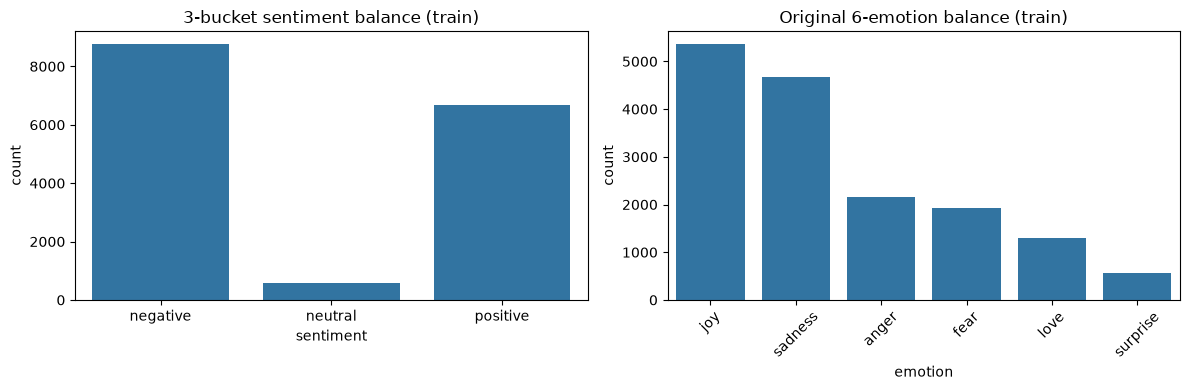

count    16000.000000
mean        19.166313
std         10.986905
min          2.000000
25%         11.000000
50%         17.000000
75%         25.000000
max         66.000000
Name: word_len, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=train_df, x="sentiment", order=["negative", "neutral", "positive"], ax=axes[0])
axes[0].set_title("3-bucket sentiment balance (train)")
sns.countplot(data=train_df, x="emotion", order=train_df["emotion"].value_counts().index, ax=axes[1])
axes[1].set_title("Original 6-emotion balance (train)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

train_df["word_len"] = train_df["text"].str.split().apply(len)
print(train_df["word_len"].describe())


## 4. Text preprocessing & vocabulary

Unlike the language-detection module, here we tokenize at the **word level**, because sentiment is
carried by whole words/phrases ("hate", "love", "annoyed"), not character patterns.

Steps:
1. Lowercase, strip URLs/mentions/hashtag-symbols (keep the hashtag word itself), strip punctuation.
2. Build a vocabulary from the training set only (avoids leakage), keeping the top-N most frequent tokens.
3. Convert every message into a fixed-length sequence of token ids (`<PAD>` / `<UNK>` handled explicitly).


In [5]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = text.replace("#", " ")
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in (train_df, val_df, test_df):
    df["clean_text"] = df["text"].apply(clean_text)
    df["tokens"] = df["clean_text"].str.split()

MAX_VOCAB_SIZE = 15000
MAX_SEQ_LEN = 30  # covers the vast majority of messages based on the length check above

PAD, UNK = "<PAD>", "<UNK>"

counter = Counter(tok for toks in train_df["tokens"] for tok in toks)
most_common = [w for w, _ in counter.most_common(MAX_VOCAB_SIZE - 2)]

itos = [PAD, UNK] + most_common
stoi = {tok: i for i, tok in enumerate(itos)}
print("Vocab size:", len(itos))

def encode(tokens, stoi=stoi, max_len=MAX_SEQ_LEN):
    ids = [stoi.get(t, stoi[UNK]) for t in tokens[:max_len]]
    ids = ids + [stoi[PAD]] * (max_len - len(ids))
    return ids

for df in (train_df, val_df, test_df):
    df["input_ids"] = df["tokens"].apply(encode)

SENTIMENT_TO_ID = {"negative": 0, "neutral": 1, "positive": 2}
for df in (train_df, val_df, test_df):
    df["label_id"] = df["sentiment"].map(SENTIMENT_TO_ID)


Vocab size: 15000


## 5. PyTorch `Dataset` / `DataLoader`

In [6]:
class SentimentDataset(Dataset):
    def __init__(self, df):
        self.X = np.stack(df["input_ids"].values)
        self.y = df["label_id"].values

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.long), torch.tensor(self.y[idx], dtype=torch.long)

BATCH_SIZE = 64

train_loader = DataLoader(SentimentDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SentimentDataset(val_df),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(SentimentDataset(test_df),  batch_size=BATCH_SIZE)


## 6. Model — Bidirectional LSTM

A small, standard architecture:
`Embedding -> BiLSTM -> mean+max pooling over time -> Dropout -> Linear(3)`

Mean+max pooling over the LSTM outputs (rather than just taking the last hidden state) tends to be more
robust for short, noisy social-media-style text.


In [7]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=3,
                 num_layers=1, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2 * 2, num_classes)  # *2 bidirectional, *2 mean+max pooling

    def forward(self, x):
        emb = self.embedding(x)                 # (B, T, E)
        out, _ = self.lstm(emb)                  # (B, T, 2H)
        mean_pool = out.mean(dim=1)
        max_pool, _ = out.max(dim=1)
        pooled = torch.cat([mean_pool, max_pool], dim=1)
        pooled = self.dropout(pooled)
        return self.fc(pooled)                   # (B, num_classes) logits

model = BiLSTMClassifier(vocab_size=len(itos)).to(DEVICE)
print(model)
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))


BiLSTMClassifier(
  (embedding): Embedding(15000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=3, bias=True)
)
Trainable params: 2185731


## 7. Training loop

Standard supervised loop with class-weighted cross-entropy (the bucketed classes are imbalanced,
as seen in the EDA plot above) and simple best-checkpoint-on-validation-F1 selection.

In [8]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=train_df["label_id"].values,
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("Class weights (neg, neutral, pos):", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.set_grad_enabled(is_train):
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            logits = model(X)
            loss = criterion(logits, y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * X.size(0)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average="macro")
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, f1

EPOCHS = 8
best_val_f1 = -1
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_f1 = run_epoch(train_loader, model, criterion, optimizer)
    val_loss, val_acc, val_f1 = run_epoch(val_loader, model, criterion, optimizer=None)
    history.append((epoch, train_loss, val_loss, train_f1, val_f1))
    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
          f"| train_f1={train_f1:.4f} val_f1={val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "best_sentiment_model.pt")
        print("  -> new best model saved")


Class weights (neg, neutral, pos): tensor([0.6087, 9.3240, 0.8001], device='cuda:0')
Epoch 01 | train_loss=0.9277 val_loss=0.5210 | train_f1=0.4546 val_f1=0.7069
  -> new best model saved
Epoch 02 | train_loss=0.3509 val_loss=0.2517 | train_f1=0.7951 val_f1=0.8715
  -> new best model saved
Epoch 03 | train_loss=0.1732 val_loss=0.1802 | train_f1=0.8861 val_f1=0.8844
  -> new best model saved
Epoch 04 | train_loss=0.1097 val_loss=0.1641 | train_f1=0.9128 val_f1=0.8911
  -> new best model saved
Epoch 05 | train_loss=0.0702 val_loss=0.1842 | train_f1=0.9344 val_f1=0.9068
  -> new best model saved
Epoch 06 | train_loss=0.0559 val_loss=0.2112 | train_f1=0.9460 val_f1=0.9008
Epoch 07 | train_loss=0.0391 val_loss=0.1842 | train_f1=0.9568 val_f1=0.9022
Epoch 08 | train_loss=0.0318 val_loss=0.1805 | train_f1=0.9627 val_f1=0.9096
  -> new best model saved


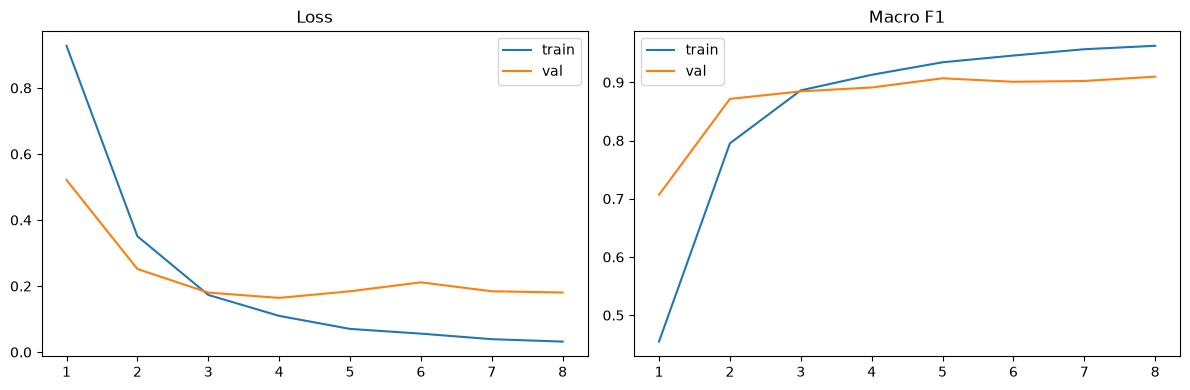

In [9]:
hist_df = pd.DataFrame(history, columns=["epoch", "train_loss", "val_loss", "train_f1", "val_f1"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(hist_df["epoch"], hist_df["train_f1"], label="train")
axes[1].plot(hist_df["epoch"], hist_df["val_f1"], label="val")
axes[1].set_title("Macro F1"); axes[1].legend()
plt.tight_layout()
plt.show()


## 8. Final evaluation on the test set

We reload the best checkpoint (best validation macro-F1) before reporting final numbers.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_6264\2295635540.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_sentiment_mode

Test accuracy: 0.9455
Test macro-F1: 0.8953776978215292

              precision    recall  f1-score   support

    negative       0.97      0.94      0.95      1080
     neutral       0.68      0.92      0.78        66
    positive       0.94      0.96      0.95       854

    accuracy                           0.95      2000
   macro avg       0.86      0.94      0.90      2000
weighted avg       0.95      0.95      0.95      2000



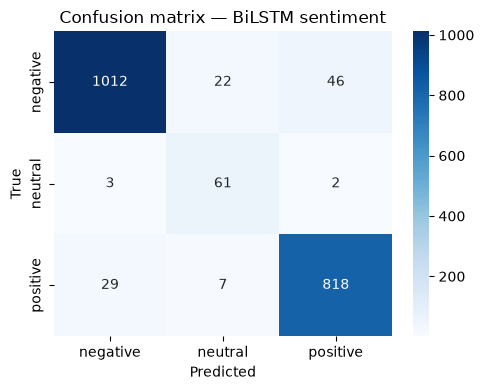

In [10]:
model.load_state_dict(torch.load("best_sentiment_model.pt", map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(DEVICE)
        logits = model(X)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(y.numpy())

ID_TO_SENTIMENT = {v: k for k, v in SENTIMENT_TO_ID.items()}
target_names = [ID_TO_SENTIMENT[i] for i in range(3)]

print("Test accuracy:", accuracy_score(all_labels, all_preds))
print("Test macro-F1:", f1_score(all_labels, all_preds, average="macro"))
print()
print(classification_report(all_labels, all_preds, target_names=target_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion matrix — BiLSTM sentiment")
plt.tight_layout()
plt.show()


## 9. Save artifacts

We save the model weights, the vocabulary (`stoi`/`itos`), and the config needed to rebuild the model
at inference time — the deployment service loads these without needing the training code.


In [11]:
import os, json, pickle

os.makedirs("../artifacts", exist_ok=True)

torch.save(model.state_dict(), "../artifacts/sentiment_bilstm.pt")

with open("../artifacts/sentiment_vocab.pkl", "wb") as f:
    pickle.dump({"stoi": stoi, "itos": itos}, f)

config = {
    "vocab_size": len(itos),
    "embed_dim": 128,
    "hidden_dim": 128,
    "num_classes": 3,
    "max_seq_len": MAX_SEQ_LEN,
    "sentiment_to_id": SENTIMENT_TO_ID,
}
with open("../artifacts/sentiment_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved model, vocab, and config to ../artifacts/")


Saved model, vocab, and config to ../artifacts/


## 10. Inference helper

Used by the integrated pipeline right after language detection, to decide the response tone/priority.

In [12]:
@torch.no_grad()
def predict_sentiment(text: str, model=model, stoi=stoi, max_len=MAX_SEQ_LEN):
    """Return (sentiment_label, is_frustrated, class_probabilities) for a single customer message."""
    model.eval()
    tokens = clean_text(text).split()
    ids = encode(tokens, stoi=stoi, max_len=max_len)
    x = torch.tensor([ids], dtype=torch.long).to(DEVICE)

    logits = model(x)
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_id = int(probs.argmax())
    label = ID_TO_SENTIMENT[pred_id]
    is_frustrated = (label == "negative")

    return label, is_frustrated, {ID_TO_SENTIMENT[i]: round(float(p), 3) for i, p in enumerate(probs)}

for sample in [
    "This is the third time my order has been delayed, I am extremely frustrated!",
    "Thank you so much, my issue was resolved quickly, great service!",
    "I would like to know the delivery options for my area.",
]:
    label, frustrated, probs = predict_sentiment(sample)
    print(f"{sample!r}\n  -> sentiment={label} | flag_priority={frustrated} | probs={probs}\n")


'This is the third time my order has been delayed, I am extremely frustrated!'
  -> sentiment=negative | flag_priority=True | probs={'negative': 0.981, 'neutral': 0.004, 'positive': 0.015}

'Thank you so much, my issue was resolved quickly, great service!'
  -> sentiment=positive | flag_priority=False | probs={'negative': 0.0, 'neutral': 0.0, 'positive': 1.0}

'I would like to know the delivery options for my area.'
  -> sentiment=negative | flag_priority=True | probs={'negative': 0.767, 'neutral': 0.014, 'positive': 0.219}

